# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from art.utils import load_mnist
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import VirtualAdversarialMethod, FastGradientMethod
from art.defences.trainer import AdversarialTrainer

import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
_ = torch.manual_seed(42)

# Load Data

In [3]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

In [4]:
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [5]:
x_train, y_train = x_train[:3000], y_train[:3000]
x_eval, y_eval = x_test[:200], y_test[:200]

In [6]:
x_train.shape, x_eval.shape

((3000, 1, 28, 28), (200, 1, 28, 28))

# Model

In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)

In [8]:
class ProbabilityCrossEntropyLoss(nn.NLLLoss):
    def forward(self, probabilities, target):
        return super().forward(torch.log(probabilities + 1e-12), target)

In [9]:
def build_classifier(seed):
    torch.manual_seed(seed)
    model = Net()
    return PyTorchClassifier(
        model=model,
        loss=ProbabilityCrossEntropyLoss(),
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
        input_shape=(1, 28, 28),
        nb_classes=10,
        clip_values=(min_pixel_value, max_pixel_value)
    )

# Baseline Model

In [10]:
baseline = build_classifier(seed=0)

In [11]:
baseline.fit(x_train, y_train, batch_size=128, nb_epochs=8, verbose=False)

In [12]:
baseline_accuracy = np.mean(np.argmax(baseline.predict(x_eval), axis=1) == np.argmax(y_eval, axis=1))
print("Baseline Clean Accuracy:", baseline_accuracy)

Baseline Clean Accuracy: 0.965


# Defence 

In [13]:
robust = build_classifier(seed=0)

In [14]:
vat_attack = VirtualAdversarialMethod(
    classifier=robust,
    max_iter=1,
    finite_diff=1e-6,
    eps=5.0,
    batch_size=64,
    verbose=False
)

In [15]:
trainer = AdversarialTrainer(classifier=robust, attacks=vat_attack, ratio=0.5)

In [16]:
trainer.fit(x_train, y_train, batch_size=128, nb_epochs=8)

Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/8 [00:00<?, ?it/s]

In [17]:
robust_classifier = trainer.get_classifier()

In [18]:
robust_accuracy = np.mean(np.argmax(robust_classifier.predict(x_eval), axis=1) == np.argmax(y_eval, axis=1))
print("Virtual Adversarial Training Clean Accuracy:", robust_accuracy)

Virtual Adversarial Training Clean Accuracy: 0.97


# Results

In [19]:
y_true = np.argmax(y_eval, axis=1)

In [20]:
def evaluate(classifier, eps):
    attack = VirtualAdversarialMethod(classifier=classifier, max_iter=3, eps=eps, batch_size=64, verbose=False)
    x_adv = attack.generate(x=x_eval)

    clean_predictions = classifier.predict(x_eval)
    adv_predictions = classifier.predict(x_adv)
    kl = np.sum(
        clean_predictions * (np.log(clean_predictions + 1e-12) - np.log(adv_predictions + 1e-12)),
        axis=1
    )
    return np.mean(np.argmax(adv_predictions, axis=1) == y_true), kl.mean()

In [21]:
print(f"{'eps':>6} | {'baseline acc':>13} | {'VAT acc':>9} | {'baseline KL':>12} | {'VAT KL':>9}")
for eps in [1.0, 2.0, 5.0, 10.0]:
    base_acc, base_kl = evaluate(baseline, eps)
    vat_acc, vat_kl = evaluate(robust_classifier, eps)
    print(f"{eps:6.1f} | {base_acc:13.3f} | {vat_acc:9.3f} | {base_kl:12.4f} | {vat_kl:9.4f}")

   eps |  baseline acc |   VAT acc |  baseline KL |    VAT KL
   1.0 |         0.950 |     0.960 |       0.0117 |    0.0048
   2.0 |         0.940 |     0.960 |       0.0518 |    0.0180
   5.0 |         0.890 |     0.920 |       0.2451 |    0.1264
  10.0 |         0.845 |     0.835 |       0.6125 |    0.3479


In [23]:
def fgsm_accuracy(classifier, eps):
    attack = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = attack.generate(x=x_eval)
    return np.mean(np.argmax(classifier.predict(x_adv), axis=1) == y_true)

In [24]:
eps_values = [0.05, 0.1, 0.15, 0.2, 0.3]
baseline_curve = [fgsm_accuracy(baseline, eps) for eps in eps_values]
robust_curve = [fgsm_accuracy(robust_classifier, eps) for eps in eps_values]

In [25]:
for eps, base_acc, vat_acc in zip(eps_values, baseline_curve, robust_curve):
    print(f"FGSM eps={eps:4.2f}  baseline={base_acc:.3f}  VAT={vat_acc:.3f}")

FGSM eps=0.05  baseline=0.930  VAT=0.935
FGSM eps=0.10  baseline=0.825  VAT=0.820
FGSM eps=0.15  baseline=0.635  VAT=0.630
FGSM eps=0.20  baseline=0.435  VAT=0.485
FGSM eps=0.30  baseline=0.100  VAT=0.080


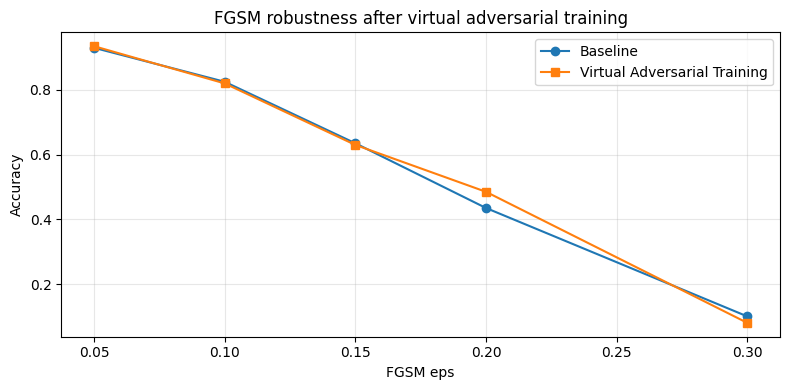

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(eps_values, baseline_curve, marker='o', label='Baseline')
plt.plot(eps_values, robust_curve, marker='s', label='Virtual Adversarial Training')
plt.xlabel('FGSM eps')
plt.ylabel('Accuracy')
plt.title('FGSM robustness after virtual adversarial training')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()